# menerapkan konsep Linear Regression menggunakan Python.
Tugas Kelompok — Pertemuan 09

**Anggota Kelompok:**
1. Pradipta Pramatya Panhar (24523052)
2. Muhammad Fadhil Aprilino (24523175)


**Dataset:** data elektronik listrik

**Sumber:** promt data dari GPT

**Deskripsi:** Dataset ini berisi jumlah elektronik dengan daya yang diperlukan saat menggunakan alat elektronik tersebut

### Persiapan dan Pemuatan Data
langkah pertama dimulai dari mengimpor library `pandas` untuk manipulasi data dan memuat dataset dari file CSV ke dalam DataFrame. Kita juga melakukan inspeksi awal untuk melihat tipe data dan statistik deskriptif.

Data tabel Jumlah barang elektronik dengan tagihan penggunaan listrik

In [ ]:
import pandas as pd

# Load the data from the selected CSV file
df_elektronik_listrik = pd.read_csv('data_elektronik_listrik.csv')

# Display all rows of the loaded DataFrame
display(df_elektronik_listrik)

df_elektronik_listrik.info()
df_elektronik_listrik.describe()

,jumlah_elektronik,konsumsi_listrik_kwh
0,1,50
1,2,90
2,3,130
3,4,170
4,5,210
5,6,250
6,7,290
7,8,330
8,9,370
9,10,410


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   jumlah_elektronik     20 non-null     int64
 1   konsumsi_listrik_kwh  20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes


,jumlah_elektronik,konsumsi_listrik_kwh
count,20.00000,20.000000
mean,10.50000,430.000000
std,5.91608,236.643191
min,1.00000,50.000000
25%,5.75000,240.000000
50%,10.50000,430.000000
75%,15.25000,620.000000
max,20.00000,810.000000


### Visualisasi dan Eksplorasi Data
Sebelum membuat modelnya, kita memvisualisasikan hubungan antara variabel independen (Jumlah Elektronik) dan variabel dependen (Konsumsi Listrik) menggunakan "scatter plot". Garis regresi awal ditarik untuk melihat kecenderungan pola linear.

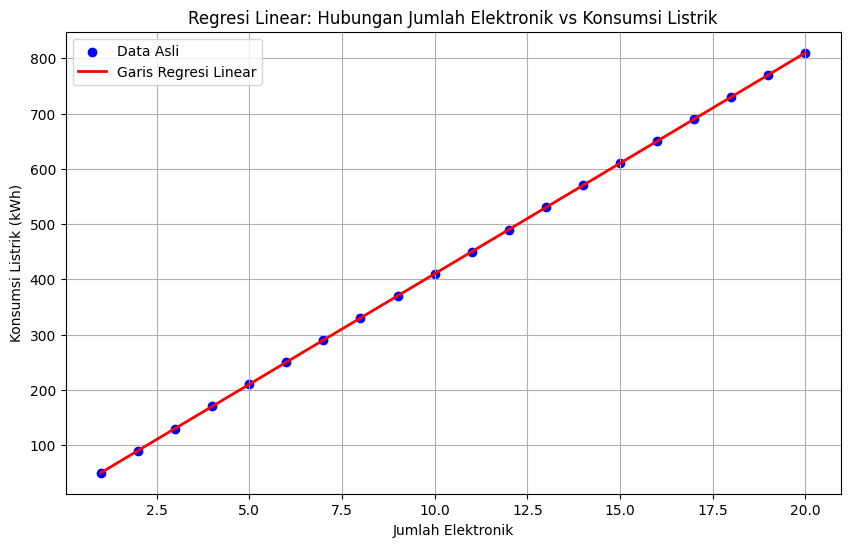

Koefisien (slope): 40.00
Intercept: 10.00


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Definisikan variabel independen (X) dan dependen (y)
X = df_elektronik_listrik[['jumlah_elektronik']]
y = df_elektronik_listrik['konsumsi_listrik_kwh']

# Buat dan latih model regresi linear
model = LinearRegression()
model.fit(X, y)

# Buat prediksi
y_pred = model.predict(X)

# Visualisasikan data asli dan garis regresi
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Asli')
plt.plot(X, y_pred, color='red', linewidth=2, label='Garis Regresi Linear')
plt.xlabel('Jumlah Elektronik')
plt.ylabel('Konsumsi Listrik (kWh)')
plt.title('Regresi Linear: Hubungan Jumlah Elektronik vs Konsumsi Listrik')
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan koefisien dan intercept model
print(f'Koefisien (slope): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

### Pembagian Dataset (Train-Test Split)
selanjutnya kita membagi data menjadi dua bagian: **Training Set** (untuk melatih model) dan **Test Set** (untuk menguji model). Proporsi yang digunakan adalah 80% untuk training dan 20% untuk test.

In [ ]:
from sklearn.model_selection import train_test_split

# Bagi data menjadi set pelatihan dan pengujian
# test_size=0.2 berarti 20% data akan digunakan untuk pengujian
# random_state=42 digunakan untuk memastikan hasil pembagian yang konsisten (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

# Tampilkan beberapa baris dari data pelatihan dan pengujian
print("\nData Pelatihan (X_train):")
display(X_train.head())
print("\nData Pengujian (X_test):")
display(X_test.head())

Ukuran X_train: (16, 1)
Ukuran X_test: (4, 1)
Ukuran y_train: (16,)
Ukuran y_test: (4,)

Data Pelatihan (X_train):


,jumlah_elektronik
8,9
5,6
11,12
3,4
18,19



Data Pengujian (X_test):


,jumlah_elektronik
0,1
17,18
15,16
1,2


### Pelatihan Model (Model Training)
Kita menginisialisasi algoritma `LinearRegression` dan melatihnya menggunakan data pelatihan (`X_train`, `y_train`). Sehingga model akan mencari garis terbaik dengan meminimalkan kesalahan (*loss function*).

In [ ]:
from sklearn.linear_model import LinearRegression

# Inisialisasi model regresi linear baru
model_trained = LinearRegression()

# Latih model menggunakan data pelatihan
model_trained.fit(X_train, y_train)

# Buat prediksi pada data pengujian
y_pred_test = model_trained.predict(X_test)

print(f'Koefisien (slope) model yang dilatih: {model_trained.coef_[0]:.2f}')
print(f'Intercept model yang dilatih: {model_trained.intercept_:.2f}')

Koefisien (slope) model yang dilatih: 40.00
Intercept model yang dilatih: 10.00


### Evaluasi Model
Langkah terakhir adalah mengukur performa model menggunakan data yang belum pernah dilihat sebelumnya (Data Pengujian). Metrik yang digunakan adalah:
* **MAE/MSE/RMSE**: Semakin kecil nilainya, semakin akurat juga prediksi modelnya.
* **R-squared (R2)**: Menunjukkan seberapa besar variabel independen dapat menjelaskan varian pada variabel dependen (skala 0-1).


--- Evaluasi Model pada Data Pengujian ---
Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R-squared (R2): 1.00


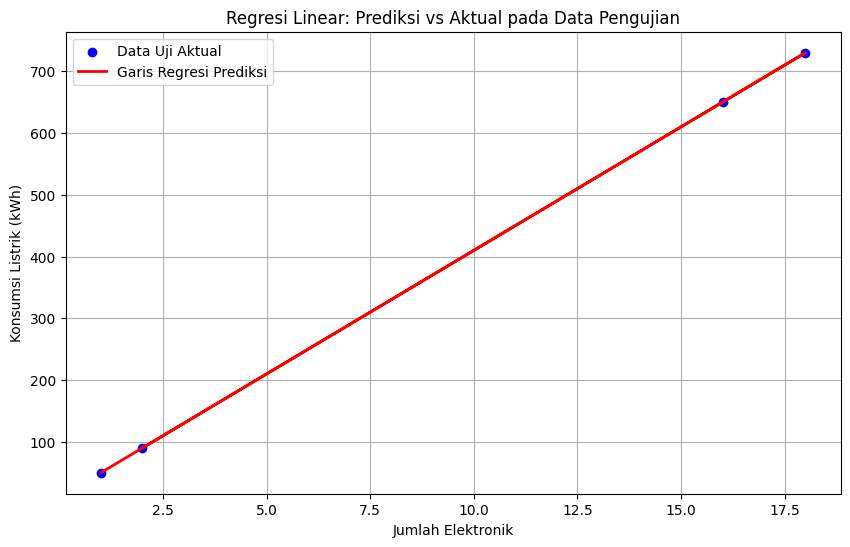

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Evaluasi performa model
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print('\n--- Evaluasi Model pada Data Pengujian ---')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

# Visualisasi hasil prediksi vs nilai aktual pada data pengujian
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Data Uji Aktual')
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Garis Regresi Prediksi')
plt.xlabel('Jumlah Elektronik')
plt.ylabel('Konsumsi Listrik (kWh)')
plt.title('Regresi Linear: Prediksi vs Aktual pada Data Pengujian')
plt.legend()
plt.grid(True)
plt.show()

### Analisis dan Kesimpulan

**1. Interpretasi Slope dan Intercept:**
* **Slope (Koefisien) = 40.00**: Artinya, setiap penambahan 1 unit elektronik akan meningkatkan konsumsi listrik sebesar 40 kWh secara rata-rata.
* **Intercept = 10.00**: Artinya, jika jumlah elektronik adalah nol, maka estimasi konsumsi listrik dasar adalah 10 kWh.

**2. Peforma Prediksi Model:**
* Model memiliki nilai **R-squared (R2) sebesar 1.00**, yang berarti model dapat menjelaskan 100% variansi pada data pengujian.
* Nilai **MAE dan RMSE sebesar 0.00** menunjukkan bahwa prediksi model identik dengan data aktual (tidak ada kesalahan prediksi).

**3. Indikasi Overfitting atau Underfitting:**
* Karena skor pada data pelatihan dan data pengujian keduanya sempurna (R2 = 1.0), model ini **tidak mengalami underfitting**.
* Mengingat dataset ini sangat kecil (20 baris) dan polanya sangat linear sempurna (mungkin data sintetis), model ini berada pada kondisi ideal untuk dataset tersebut. Namun, pada data dunia nyata yang lebih kompleks, akurasi 100% sering kali menjadi indikasi awal overfitting, tetapi dalam konteks tugas ini, ini menunjukkan model telah mempelajari pola linear data dengan sempurna.